<a href="https://colab.research.google.com/github/hpatel2004/scratchpad/blob/main/03_assignment_linear_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3: Linear Models

In [39]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import plotly.express as px

! git clone https://github.com/hpatel2004/scratchpad
%run ./scratchpad/get_data.py


fatal: destination path 'scratchpad' already exists and is not an empty directory.


<Figure size 640x480 with 0 Axes>

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?

A model is linear if the equation being used to predict values has a linear combination of features and coefficients.

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)

You would drop one of the categories (baseline) to eliminate multicollinearity. Then, the model's intercept will be interpreted as the prediction for the baseline category. The coefficient of a dummy variable, therefore, will represent the difference between that variable and the baseline category while holding other variables constant.

3. Can linear regression be used for classification? Explain why, or why not.

Technically, linear regression could be utilized for classification by classifying based on the numerical value being output and establishing a threshold. However, they are inherently different problems, as classification deals with discrete categories while linear regression utilizes continuous variables. Furthermore, linear regression could classify values outside of the given thresholds, creating false classifications.

4. What are signs that your linear model is over-fitting?

A model is over-fitting when the model performs with little error on the training data but very high error on the testing data or other unseen data.

5. Clearly explain multi-colinearity using the two-stage least squares technique.

Multicollinearity is when two or more variables are highly correlated. Two-stage least squares technique minimizes this problem by regressing the highly correlated value on the other variables, then utilizing those predictive values in the linear model instead of the original variable. By removing that correlation, you can more clearly see the relationships of individual variables.

6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?

You can transform the features with nonlinear relationship to have a linear relationship by introducing polynomials (squared, cubed) or logs.

7. What is the interpretation of the slope coefficient in a linear regression?

The slope coefficient $β_j$ represents the expected change in the response variable due to a 1-unit increase in the variable $x_j$ only, while all other variables remain constant.

8. Compare the train/test split and $k$-fold cross validation.

The train-test split divides the data into a train set and test set (usually 80-20). The model will train on the train set and validate results on the test set.

$k$-fold cross validation divides the data into $k$ folds, or batches. The model will be trained $k$ times, where each time a fold is omitted for validation. The performance is then averaged across the $k$ iterations.

9. How is the $k$ in $k$-fold cross validation typically selected?

$k$ isn't really a hyperparameter to be tuned, so traditionally $5$ or $10$ is selected as they have reliable performance results.


**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.

On average, Manhattan is the most expensive borough.

2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?

I dropped the first category (Bronx) with an intercept included. Therefore, every coefficient represents the difference in price between that neighborhood and the Bronx. We notice that each coefficient matches the difference between the neighborhood's mean price and the Bronx's mean price. The intercept does not equal Bronx mean because it predicts the Bronx price for when all the other variables are zero, which is unrealistic for variables such as "Review Score Ratings".

3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.

The slope coefficient is $1.0208$, meaning that for every one point increase in `Review Scores Rating`, the price increases on average by $1.02$.

4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?

The slope coefficient is now $1.0811$, meaning that the change in price is slightly larger when conditioned on the neighborhood.

5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?

The slopes are fairly similar across the neighborhoods, as seen with the low significance values for Queens, Brooklyn, and Manhattan. However, the most concerning stat is the high significance an dstrongly negative slope for Staten Island, indicating that the slope for Staten Island is vastly different than the slope for the Bronx.

6. Use cross validation to evaluate the models from parts 4, 5, and 6.

The cross validation shows that the best model with the lowest MSE is model 2, which was the model that included the neighborhood and the `Review Scores Rating`.

In [40]:
df = pd.read_csv('Q1_clean.csv')
print(df.head())
print(df.columns)
df = df.rename(columns={"Neighbourhood ": "Neighbourhood"}) # trailing space

# QUESTION 1
avg_stats = df.groupby("Neighbourhood")[["Price", "Review Scores Rating"]].mean()
print(avg_stats)

# check dtypes
print(df.dtypes)

# QUESTION 2
print("\nQUESTION 2:")
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
df["Review Scores Rating"] = pd.to_numeric(df["Review Scores Rating"], errors="coerce")

neigh_dummies = pd.get_dummies(df["Neighbourhood"], drop_first=True).astype(int)

X = pd.concat([neigh_dummies, df["Review Scores Rating"]], axis=1)

X = sm.add_constant(X)
y = df["Price"]

model = sm.OLS(y, X).fit()

print(model.summary())

print(df.groupby("Neighbourhood")["Price"].mean())


# QUESTION 3
print('\nQUESTION 3:')
X1 = sm.add_constant(df["Review Scores Rating"])
y = df["Price"]
model1 = sm.OLS(y, X1).fit()
print(model1.summary())

# QUESTION 4
print("\nQUESTION 4:")
X2 = pd.concat([neigh_dummies, df["Review Scores Rating"]], axis=1)
X2 = sm.add_constant(X2)
model2 = sm.OLS(y, X2).fit()
print(model2.summary())

# QUESTION 5
print("\nQUESTION 5:")
model_interaction = smf.ols(
    "Price ~ C(Neighbourhood) * Q('Review Scores Rating')",
    data=df
).fit()

print(model_interaction.summary())

# QUESTION 6
print("\nQUESTION 6:")

X1 = df[["Review Scores Rating"]]

X2 = pd.get_dummies(df[["Neighbourhood"]], drop_first=True)
X2["Review Scores Rating"] = df["Review Scores Rating"]

X3 = pd.get_dummies(df[["Neighbourhood"]], drop_first=True)
X3["Review Scores Rating"] = df["Review Scores Rating"]

for col in X3.columns:
    if col != "Review Scores Rating":
        X3[f"{col}_x_rating"] = X3[col] * df["Review Scores Rating"]

y = df["Price"]

kf = KFold(n_splits=10, shuffle=True, random_state=1)

def compute_cv_mse(X, y):
    model = LinearRegression()
    scores = cross_val_score(
        model, X, y,
        scoring="neg_mean_squared_error",
        cv=kf
    )
    return -scores.mean()

mse1 = compute_cv_mse(X1, y)
mse2 = compute_cv_mse(X2, y)
mse3 = compute_cv_mse(X3, y)

print(f"Model 1 (Rating only): {mse1:.3e}")
print(f"Model 2 (Neighborhood + Rating): {mse2:.3e}")
print(f"Model 3 (Interaction): {mse3:.3e}")

   Price  Review Scores Rating Neighbourhood  Property Type        Room Type
0    549                  96.0      Manhattan     Apartment     Private room
1    149                 100.0       Brooklyn     Apartment  Entire home/apt
2    250                 100.0      Manhattan     Apartment  Entire home/apt
3     90                  94.0       Brooklyn     Apartment     Private room
4    270                  90.0      Manhattan     Apartment  Entire home/apt
Index(['Price', 'Review Scores Rating', 'Neighbourhood ', 'Property Type',
       'Room Type'],
      dtype='object')
                    Price  Review Scores Rating
Neighbourhood                                  
Bronx           75.276498             91.654378
Brooklyn       127.747378             92.363497
Manhattan      183.664286             91.801496
Queens          96.857233             91.549057
Staten Island  146.166667             90.843750
Price                     int64
Review Scores Rating    float64
Neighbourhood       

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?

The car types that are the most expensive are typically SUVs, followed closely by sedans. The car types with the most variance (i.e., the widest regions on the histogram) are SUVs, again followed closely by sedans. In contrast, hatchbacks have a smaller variance.

  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?

The slope coefficient is 5.927e+04, meaning that for every one seat increase in seating capacity, the price increases on average by 59270 rupees. After hot-encoding seating capacity, we can see that the price difference is *not* linear in the number of seats. Specifically, there is a huge jump when the seat number is 7 (7.359e+05) versus 6 and 8. Additionally, the $R^2$ values for both regressions are very low (0.005, 0.022), indicating that this relationship cannot be represented well through a linear model.

  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.

Given the list of MSEs from this cross-validation, the optimal degree to use is $11$, as it produced the smallest MSE ($9.516*10^{10}$). However, any degree between 6 to 12 would be acceptable as the MSE lingers around $9.5*10^{10}$.

  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?

  Yes, the model accurately fits the pattern in the data, which is that as the age of a car increases, the price tends to decrease. The polynomial model does a good job of accounting for the slight price increase when a car is aged $6$ years.


count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64
Index(['Unnamed: 0', 'Make', 'Make_Year', 'Color', 'Body_Type', 'Mileage_Run',
       'No_of_Owners', 'Seating_Capacity', 'Fuel_Type', 'Transmission',
       'Transmission_Type', 'Price'],
      dtype='object')


                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.075
Date:                Tue, 24 Mar 2026   Prob (F-statistic):             0.0245
Time:                        17:45:15   Log-Likelihood:                -13888.
No. Observations:                 976   AIC:                         2.778e+04
Df Residuals:                     974   BIC:                         2.779e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              4.39e+05   1.35e+05  

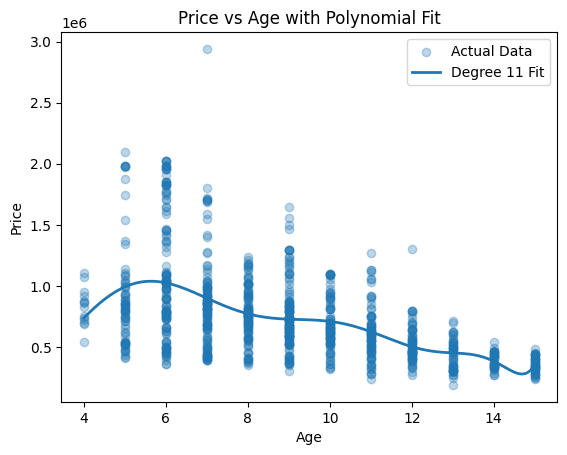

In [41]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import matplotlib.pyplot as plt

df = pd.read_csv('./data/cars_hw.csv')

# QUESTION 1
print(df["Price"].describe())
print(df.columns)
fig = px.histogram(df, x="Price", nbins=50, marginal="rug", histnorm="density")
fig.update_layout(title="Distribution of Car Prices (Density Approximation)")
fig.show()

fig = px.histogram(
    df,
    x="Price",
    color="Body_Type",
    nbins=50,
    histnorm="density",
    opacity=0.5
)

fig.update_layout(title="Price Distribution by Body Type")
fig.show()


# QUESTION 2
X = df["Seating_Capacity"]
X = sm.add_constant(X)
y = df["Price"]

model = sm.OLS(y, X).fit()
print(model.summary())

import statsmodels.formula.api as smf

model_cat = smf.ols("Price ~ C(Seating_Capacity)", data=df).fit()
print(model_cat.summary())

df.groupby("Seating_Capacity")["Price"].mean()

# QUESTION 3
print("QUESTION 3\n")
df["Age"] = 2026 - df["Make_Year"]
X = df[["Age"]]
y = df["Price"]

kf = KFold(n_splits=10, shuffle=True, random_state=1)

degrees = range(1, 15)
cv_errors = []

for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_poly = poly.fit_transform(X)

    model = LinearRegression()

    scores = cross_val_score(model, X_poly, y,
                             scoring="neg_mean_squared_error",
                             cv=kf)

    mse = -scores.mean()
    cv_errors.append(mse)

for d, err in zip(degrees, cv_errors):
    print(f"Degree {d}: CV MSE = {err:.3e}")

# QUESTION 4

best_degree = 11 # selected from previous question

X = df[["Age"]].values
y = df["Price"].values

poly = PolynomialFeatures(degree=best_degree, include_bias=False)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

age_grid = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
age_grid_poly = poly.transform(age_grid)
y_pred = model.predict(age_grid_poly)

plt.scatter(X, y, alpha=0.3, label="Actual Data")
plt.plot(age_grid, y_pred, linewidth=2, label=f"Degree {best_degree} Fit")

plt.xlabel("Age")
plt.ylabel("Price")
plt.title("Price vs Age with Polynomial Fit")
plt.legend()
plt.show()

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?

The ATE on three-year survival for heart transplant interventions is 0.2302, or 23.03%.

2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.

The intercept in the regression is $0.1176$, which matches the control group survival rate. The coefficient on transplant is $0.2302$, which exactly matches the ATE computed in part 1. This confirms that in a simple linear regression with a binary treatment variable, the intercept represents the control mean and the slope represents the difference in means between treatment and control.

After controlling for age, the estimated effect of transplant increases to $0.2647$, suggesting that age was a confounding variable, which makes intuitive sense. Accounting for age reveals a stronger positive effect of transplant on survival. The intercept $0.7020$ represents the predicted survival probability for a control individual with age 0, which has no meaning. The coefficient on age $-0.0136$ indicates that each additional year of age reduces survival probability by about $1.36$ percentage points.

3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?

The ATE assumes a constant treatment effect across all ages, but the regression model shows that survival varies with age. As a result, the ATE may overestimate the effect for younger individuals (who already have higher survival) and underestimate the effect for older individuals (who have lower baseline survival).

4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?

Allowing for an interaction between transplant and age changes the model by making the treatment effect depend on age. The negative interaction term (-0.0146) indicates that the benefit of a transplant decreases as age increases. This means younger patients benefit more from transplants, while older patients benefit less.

5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.

Adding age substantially improves predictive accuracy, as seen with the comparison of model 2 versus model 1. Including the interaction term in model 3 provides a small additional improvement, suggesting that allowing the treatment effect to vary with age slightly improves model performance, although the gain is modest.

6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?

The treatment assignment is not randomized, so the estimated effects may be biased due to confounding variables such as underlying health conditions. Second, the model relies heavily on age as opposed to other health-related variables. Third, the model assumes relatively simple linear relationships and may fail to capture important medical complexities. In any case, using predictive models for life-or-death decisions risks reinforcing existing biases in the data and may lead to grave consequences.

In [42]:
df = pd.read_csv("data/heart_hw.csv")
print(df.head())
# Convert transplant to binary
df["transplant_bin"] = (df["transplant"] != "control").astype(int)

# Drop useless column
df = df.drop(columns=["Unnamed: 0"])
print(df.head())

# QUESTION 1
control_mean = df[df["transplant_bin"] == 0]["y"].mean()
treatment_mean = df[df["transplant_bin"] == 1]["y"].mean()

ATE = treatment_mean - control_mean

print(f"Control survival rate: {control_mean:.4f}")
print(f"Treatment survival rate: {treatment_mean:.4f}")
print(f"ATE (Treatment - Control): {ATE:.4f}")

# QUESTION 2
X = sm.add_constant(df["transplant_bin"])
y = df["y"]

model1 = sm.OLS(y, X).fit()
print(model1.summary())

# QUESTION 3
X = sm.add_constant(df[["transplant_bin", "age"]])
model2 = sm.OLS(y, X).fit()
print(model2.summary())

# QUESTION 4
df["interaction"] = df["transplant_bin"] * df["age"]

X = sm.add_constant(df[["transplant_bin", "age", "interaction"]])
model3 = sm.OLS(y, X).fit()
print(model3.summary())

# QUESTION 5
kf = KFold(n_splits=10, shuffle=True, random_state=1)

y = df["y"]

X1 = df[["transplant_bin"]]
X2 = df[["transplant_bin", "age"]]
X3 = df[["transplant_bin", "age", "interaction"]]

def cv_mse(X, y):
    model = LinearRegression()
    scores = cross_val_score(model, X, y,
                             scoring="neg_mean_squared_error",
                             cv=kf)
    return -scores.mean()

print("Model 1:", cv_mse(X1, y))
print("Model 2:", cv_mse(X2, y))
print("Model 3:", cv_mse(X3, y))

   Unnamed: 0  age transplant  y
0           1   53    control  0
1           2   43    control  0
2           3   52    control  0
3           4   52    control  0
4           5   54    control  0
   age transplant  y  transplant_bin
0   53    control  0               0
1   43    control  0               0
2   52    control  0               0
3   52    control  0               0
4   54    control  0               0
Control survival rate: 0.1176
Treatment survival rate: 0.3478
ATE (Treatment - Control): 0.2302
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Tue, 24 Mar 2026   Prob (F-statistic):             0.0133
Time:                        17:45:17   Log-Likelihood:                -59.591
No. Observ